In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import metrics
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [16]:
data = pd.read_csv("Dataset_ATS_v2.csv")

In [17]:
# Binary encoding
# Binary categorical variables were encoded using 0/1 mapping.
data["gender"] = data["gender"].map({"Female": 0, "Male": 1})
data["Dependents"] = data["Dependents"].map({"No": 0, "Yes": 1})
data["PhoneService"] = data["PhoneService"].map({"No": 0, "Yes": 1})
data["MultipleLines"] = data["MultipleLines"].map({"No": 0, "Yes": 1})
data["InternetService"] = data["InternetService"].map({
    "DSL": 0,
    "Fiber optic": 1
})
data["Churn"] = data["Churn"].map({"No": 0, "Yes": 1})

In [18]:
# Label encoding
# Label encoding was applied to ordinal categorical variables where a natural order exists.
contract_map = {
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
}
data["Contract"] = data["Contract"].map(contract_map)

print("\nThe data after encoding:\n")
print(data)



The data after encoding:

      gender  SeniorCitizen  Dependents  tenure  PhoneService  MultipleLines  \
0          0              0           0       1             0              0   
1          1              0           0      41             1              0   
2          0              0           1      52             1              0   
3          0              0           0       1             1              0   
4          1              0           0      67             1              0   
...      ...            ...         ...     ...           ...            ...   
7038       1              0           0       1             1              1   
7039       0              0           1      23             1              1   
7040       1              0           1      12             1              0   
7041       1              1           0      12             1              1   
7042       1              0           0      26             1              0   

      Intern

In [19]:
# ================= split dataset into train and test sets ========================
# target and features
X = data.drop(columns=["Churn"])
y = data["Churn"]
# split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify = y
)
print("\nTraining set shape:", X_train.shape)
print("\nTest set shape:", X_test.shape)


Training set shape: (5634, 9)

Test set shape: (1409, 9)


In [20]:
'''
# MinMax Method
scaler = MinMaxScaler()
# normalises all features to the [0,1] range
numeric_cols = ["tenure", "MonthlyCharges"]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Only scaling numeric variable
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])
'''

'\n# MinMax Method\nscaler = MinMaxScaler()\n# normalises all features to the [0,1] range\nnumeric_cols = ["tenure", "MonthlyCharges"]\n\nX_train_scaled = X_train.copy()\nX_test_scaled = X_test.copy()\n\n# Only scaling numeric variable\nX_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])\nX_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])\n'

In [21]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

In [22]:
X_train_scaled

,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges
3757,1,0,1,1,1,0,0,2,60
3165,0,0,0,30,1,0,0,1,55
4912,0,1,0,46,1,1,1,0,100
3877,1,0,0,43,1,0,0,1,66
3818,1,0,0,1,1,1,1,2,20
...,...,...,...,...,...,...,...,...,...
6335,0,0,1,9,1,0,0,0,55
6153,1,0,0,2,1,0,0,2,54
4508,1,0,0,12,1,0,0,0,57
2727,1,0,1,35,1,1,1,0,20


In [23]:
# ==================== export train and test =========================

# combine X and y
train_final = X_train_scaled.copy()
train_final["Churn"] = y_train

test_final = X_test_scaled.copy()
test_final["Churn"] = y_test

X_full_scaled = pd.concat([X_train_scaled, X_test_scaled])

# Export
X_full_scaled.to_csv("X_full_noscale_scaled.csv", index=False)

In [24]:
data = pd.read_csv("X_full_noscale_scaled.csv")


In [25]:
# elbow method
sse = []
silhouette_scores = []

k_range = range(1, 11)

for k in k_range:
    #kmeans = KMeans(n_clusters = k, random_state=42, n_init=10)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(data)
    sse.append(kmeans.inertia_)

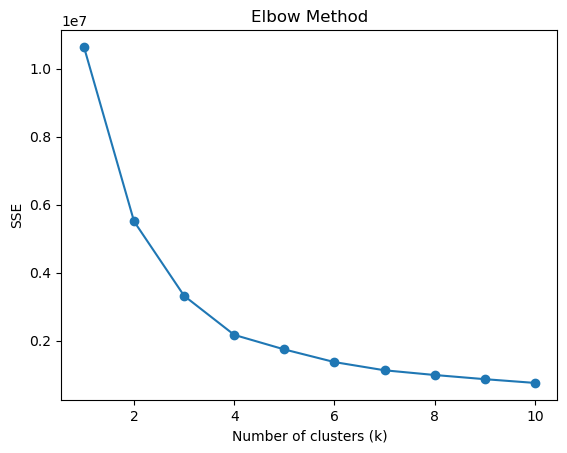

In [26]:
# Plot Elbow Method

plt.plot(k_range, sse, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("SSE")
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


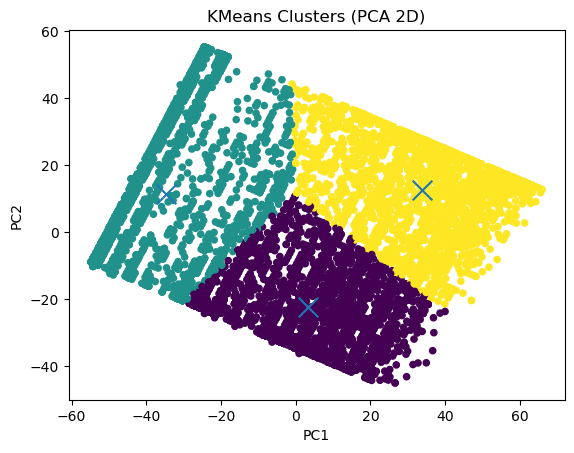

In [30]:
# according to the elbow plot, k = 4 is selected as the optimal number of clusters ...
# KMeans clustering
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(data)
# PCA for 2D visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(data)
centers_pca = pca.transform(kmeans.cluster_centers_)
# Plot
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=20)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], marker="x", s=200)
plt.title("KMeans Clusters (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [31]:
# Original Cleaned data
data_original = pd.read_csv("Dataset_ATS_v2.csv")

data_original["gender"] = data_original["gender"].map({"Female": 0, "Male": 1})
data_original["Dependents"] = data_original["Dependents"].map({"No": 0, "Yes": 1})
data_original["PhoneService"] = data_original["PhoneService"].map({"No": 0, "Yes": 1})
data_original["MultipleLines"] = data_original["MultipleLines"].map({"No": 0, "Yes": 1})
data_original["InternetService"] = data_original["InternetService"].map({"DSL": 0, "Fiber optic": 1})
data_original["Churn"] = data_original["Churn"].map({"No": 0, "Yes": 1})

contract_map = {
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
}
data_original["Contract"] = data_original["Contract"].map(contract_map)

data_original["Cluster"] = labels


In [32]:
data_original.groupby("Cluster").mean()

,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Churn
Cluster,,,,,,,,,,
0,0.499797,0.157788,0.293615,32.345669,0.900366,0.420089,0.437983,0.703131,64.777552,0.276129
1,0.506532,0.162242,0.312263,32.354825,0.902655,0.429414,0.450063,0.683944,64.235145,0.259587
2,0.508367,0.166893,0.292628,32.417006,0.906829,0.415649,0.430122,0.683401,65.299864,0.259611
